# Poisson equation in a multi-patch domain

In [1]:
%matplotlib inline

import numpy as np
import scipy
import matplotlib.pyplot as plt
import itertools

np.set_printoptions(linewidth=100000)

from pyiga import bspline, assemble, vform, geometry, vis, solvers, topology, adaptive
from pyiga import assemble_cy

In [2]:
# define discretization space (we may choose nested discretization spaces)
p = 3
N = 10
kvs = [2 * (bspline.make_knots(p, 0.0, 1.0, N),),
       2 * (bspline.make_knots(p, 0.0, 1.0, N),),
       2 * (bspline.make_knots(p, 0.0, 1.0, N),),
       2 * (bspline.make_knots(p, 0.0, 1.0, N),)]

In [3]:
# define geometry
geos = [
    geometry.quarter_annulus(),
    geometry.unit_square().translate((-1, 1)),
    geometry.quarter_annulus().rotate_2d(np.pi).translate((-1, 3)),
    geometry.quarter_annulus().rotate_2d(-np.pi/2).translate((-2, 1))
]

patches = [(kv, g) for kv,g in zip(kvs,geos)]

In [4]:
# source term f and Dirichlet boundary function g
f  = lambda x, y: np.exp(-5 * ((x-0.3)**2 + (y-1)**2))
gD = lambda x, y: 1e-1 * np.sin(8*x)

# Robin boundary data such that \partial_n u + alpha * u = g1, if alpha=0 this represents also a Neumann boundary condition.
gN = lambda x, y: 0.
alpha = lambda x, y: 0.

# set up a PatchMesh object, which detects interfaces between patches
M = topology.MultiPatch(patches)

# by default all outer boundaries are given the index 0, which we will use for the Dirichlet boundary
# let us generate a Neumann boundary indexed by 1
M.set_boundary_id({'Neumann/Robin':{(0,'left'),(2,'right'),(3,'left'),(3,'right')},
                   'Dirichlet':{(0,'bottom'),(0,'right'),(1,'top'),(2,'bottom'),(2,'left'),(3,'bottom')}})

# set up a MultiPatch object that initializes a Basis to map global dofs to local dofs
MP = assemble.MultiBasis(M, automatch=True)

# set Dirichlet values for DoFs at the Dirichlet boundary
dir_bcs = MP.set_dirichlet_boundary({'Dirichlet':gD})

# assemble the linear system and (possible) Neumann vector or Robin matrix/vector
Kh = MP.assemble_volume("inner(grad(u), grad(v)) * dx", arity = 2)
Fh = MP.assemble_volume("f * v * dx", arity=1, physical=True, f=f) #f is living in the physical domain

# generate Neumann vector for global contribution to the right hand side, in this case it is a zero vector since g1 is zero
Nh = MP.assemble_surface('(gN * v) * ds', arity=1, gN=gN, boundary_idx='Neumann/Robin')

# generate Robin Matrix for global contribution to the right hand side, in this case it is a zero matrix again since alpha is zero
Rh = MP.assemble_surface('(alpha * u * v) * ds', arity=2, alpha=alpha, boundary_idx='Neumann/Robin')

setting up constraints took 0.0044708251953125 seconds.
Basis setup took 0.0015501976013183594 seconds


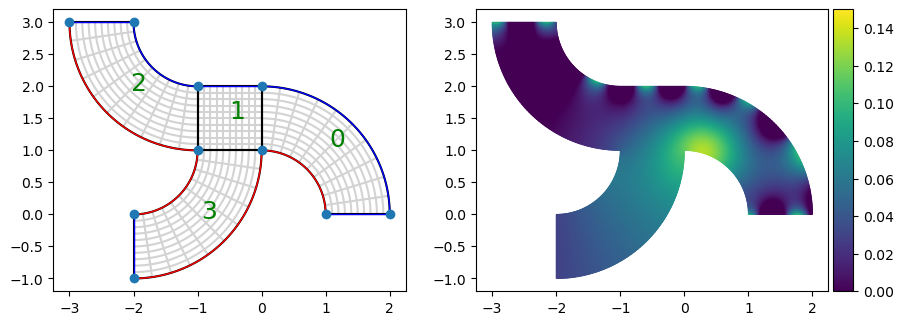

In [5]:
# set up and solve linear system by eliminating Dirichlet DoFs from the system
LS = assemble.RestrictedLinearSystem(Kh + Rh, Fh + Nh, dir_bcs)
u = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

# restrict solution to each individual patch (kvs on every patch) and visualize solution together with the mesh
fig, ax = plt.subplots(1,2,figsize=(10,5))
M.plotmesh(patch_idx = True, knots=True, nodes=True, bcolor={'Dirichlet':'blue','Neumann/Robin':'red'}, axis=ax[0])
MP.plot(u, range = (0, 1.5e-1),cbar=True, cmap='viridis', axis=ax[1], aspect='equal', cbar_width=0.2, cbar_pad = 0.05);
ax[0].axis('scaled'); #ax[1].axis('scaled');

# Computerchip

In [39]:
# define geometry
def ComputerChip(p, N):
    geos = [
        geometry.Quad(np.array([[0,0.5,0.35, 0.5],[0,0,0.3,0.15]])),
        geometry.Quad(np.array([[0, 0.35, 0, 0.17],[0, 0.3, 0.6, 0.6]])),
        geometry.Quad(np.array([[0.35, 0.5, 0.17, 0.5],[0.3, 0.45, 0.6, 0.6]])),
        geometry.Quad(np.array([[0.17, 0.5, 0.17, 0.5],[0.6, 0.6, 0.8, 0.8]])),
        geometry.Quad(np.array([[0.5,1,0.5, 0.65],[0,0,0.15,0.3]])),
        geometry.Quad(np.array([[0.65, 1, 0.83, 1],[0.3,0,0.6,0.6]])),
        geometry.Quad(np.array([[0.5,0.65,0.5,0.83],[0.45,0.3,0.6,0.6]])),
        geometry.Quad(np.array([[0.5, 0.83, 0.5, 0.83],[0.6, 0.6, 0.8, 0.8]])),
    ]

    kvs = 8 * [2 * (bspline.make_knots(p, 0.0, 1.0, N),)]
    
    patches = [(kv, g) for kv,g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    
    M.set_boundary_id({'Dirichlet':{(0,'top'),(2,'bottom'),(4,'top'),(6,'bottom')},
                       'Neumann':{(1,'top'),(1,'left'),(3,'top'),(3,'left'),(5,'top'),(5,'right'),(7,'top'),(7,'right')},
                       'Robin' : {(0,'bottom'),(4,'bottom')}})
    M.set_domain_id({0:{0,1,2,4,5,6}, 1:{3,7}})
    return M

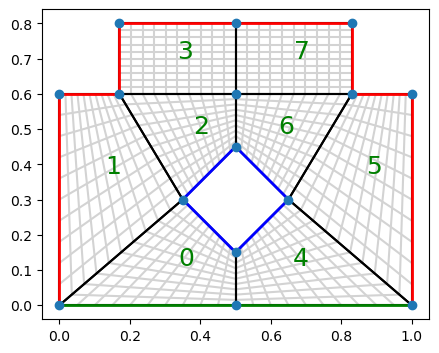

In [40]:
M = ComputerChip(3,10)

# visualize the PatchMesh object with Dirichlet boundary (blue) and Neumann boundary (red)
M.plotmesh(patch_idx = True, knots=True, nodes=True, bcolor={'Dirichlet':'blue','Neumann':'red','Robin':'green'}, bwidth=2)
plt.axis('scaled');

In [41]:
M.interfaces

{(0, 2, 0): ((1, 0, 0), (False,)),
 (1, 0, 0): ((0, 2, 0), (False,)),
 (0, 3, 0): ((4, 2, 0), (False,)),
 (4, 2, 0): ((0, 3, 0), (False,)),
 (1, 3, 0): ((2, 2, 0), (False,)),
 (2, 2, 0): ((1, 3, 0), (False,)),
 (2, 1, 0): ((3, 0, 0), (False,)),
 (3, 0, 0): ((2, 1, 0), (False,)),
 (2, 3, 0): ((6, 2, 0), (False,)),
 (6, 2, 0): ((2, 3, 0), (False,)),
 (3, 3, 0): ((7, 2, 0), (False,)),
 (7, 2, 0): ((3, 3, 0), (False,)),
 (4, 3, 0): ((5, 0, 0), (True,)),
 (5, 0, 0): ((4, 3, 0), (True,)),
 (5, 2, 0): ((6, 3, 0), (False,)),
 (6, 3, 0): ((5, 2, 0), (False,)),
 (6, 1, 0): ((7, 0, 0), (False,)),
 (7, 0, 0): ((6, 1, 0), (False,))}

In [31]:
kappa = 130.0
alpha = 0.2
f = lambda x,y: 0.0
gN = lambda x,y: 0.0
gD = lambda x,y: 500.0
gR = lambda x,y: 300.0*alpha
lam = {0:0.01, 1:3.95}

In [32]:
MP = assemble.MultiBasis(M, automatch=True)

# set Dirichlet values for DoFs at the Dirichlet boundary
dir_bcs = MP.set_dirichlet_boundary({'Dirichlet':gD})

# assemble the linear system and (possible) Neumann vector or Robin matrix/vector
Kh = sum([MP.assemble_volume("lam * inner(grad(u), grad(v)) * dx", arity = 2, domain_id=i, lam=lam[i]) for i in range(2)]) 
Fh = MP.assemble_volume("f * v * dx", arity=1, f=f) #f is living in the physical domain

# generate Neumann vector for global contribution to the right hand side, in this case it is a zero vector since g1 is zero
Nh = MP.assemble_surface('(gN * v) * ds', arity=1, gN=gN, boundary_idx='Neumann')

# generate Robin Matrix for global contribution to the right hand side, in this case it is a zero matrix again since alpha is zero
Rh = MP.assemble_surface('(alpha * u * v) * ds', arity=2, alpha=alpha, boundary_idx='Robin')
Nh += MP.assemble_surface('(gR * v) * ds', arity=1, gR=gR, boundary_idx='Robin')

setting up constraints took 0.033551931381225586 seconds.
Basis setup took 0.004784822463989258 seconds


In [33]:
LS = assemble.RestrictedLinearSystem(Kh + Rh, Fh + Nh, dir_bcs)
u = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

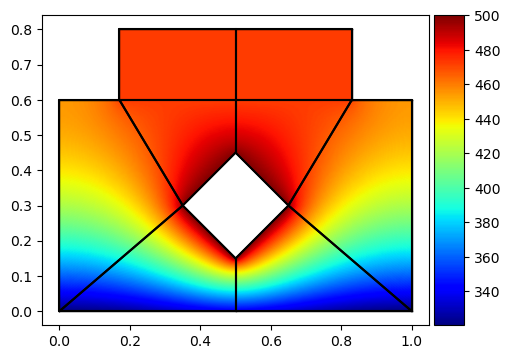

In [35]:
MP.plot(u, cbar=True, cmap='jet', aspect='equal', figsize=(5,5), physical=True, mesh=True);

# Using non-matching multi-patch domains for adaptive refinement

In [36]:
def solveChip(MP, lam, f):
    kappa = 130.0
    alpha = 0.2
    gN = lambda x,y: 0.0
    gD = lambda x,y: 500.0
    gR = lambda x,y: 300.0*alpha

    Kh = sum([MP.assemble_volume("lam * inner(grad(u), grad(v)) * dx", arity = 2, domain_id=i, lam=lam[i]) for i in range(len(lam))])
    Fh = sum([MP.assemble_volume("f * v * dx", arity=1, domain_id = i, f=f[i]) for i in range(2)]) #f is living in the physical domain

    Nh = MP.assemble_surface('(gN * v) * ds', arity=1, gN=gN, boundary_idx='Neumann')
    Rh = MP.assemble_surface('(alpha * u * v) * ds', arity=2, alpha=alpha, boundary_idx='Robin')
    Nh += MP.assemble_surface('(gR * v) * ds', arity=1, gR=gR, boundary_idx='Robin')

    LS = assemble.RestrictedLinearSystem(Kh + Rh, Fh + Nh, dir_bcs)
    return LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

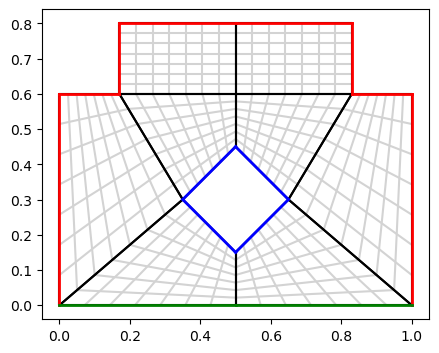

setting up constraints took 0.011575460433959961 seconds.
Basis setup took 0.0018277168273925781 seconds
34.60895383631789


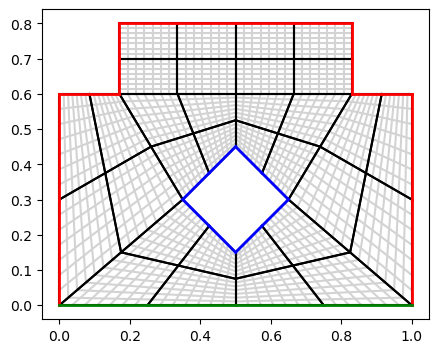

setting up constraints took 0.06233549118041992 seconds.
Basis setup took 0.0022115707397460938 seconds
29.896900770758243


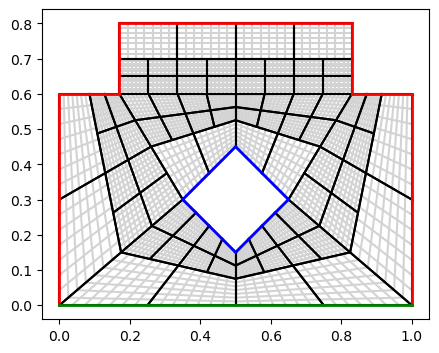

setting up constraints took 0.18393969535827637 seconds.
Basis setup took 0.003687620162963867 seconds
22.996897758207023


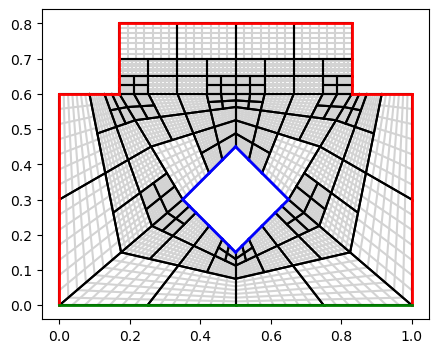

setting up constraints took 0.32683515548706055 seconds.
Basis setup took 0.0050928592681884766 seconds


KeyboardInterrupt: 

In [37]:
M = ComputerChip(4,7)

maxiter=20
it=0
lam = {0:0.01, 1:3.95}
f = {0:0., 1:0.}
while True:
    M.plotmesh(figsize=(5,5),patch_idx = False, knots=True, nodes=False, 
               bcolor={'Dirichlet':'blue','Neumann':'red','Robin':'green'}, bwidth=2)
    plt.axis('scaled');
    plt.show()

    MP = assemble.MultiBasis(M, automatch=True)
    dir_bcs = MP.set_dirichlet_boundary({'Dirichlet':gD})

    #assemble and solve
    u = solveChip(MP, lam, f)

    #estimate
    err_ind = adaptive.mp_resPois(MP,u,a=lam, f=f)
    eta=np.linalg.norm(err_ind)
    print(eta)
    if eta < 1e-4:
        print("#############################################################")
        print("Terminated successfully after {} iterations".format(it))
        print("#############################################################")
        break
    if it==maxiter:
        print("Iteration hit maximal number of iterations ({}).".format(maxiter))

    #mark
    marked_patches = adaptive.doerfler_mark(err_ind, theta=0.95, TOL=0.05)

    #refine
    M.h_refine(patches=marked_patches,ref="rs");
    it+=1
    
MP.plot(u, cbar=True, cmap='jet', aspect='equal', figsize=(5,5), physical=True);